<a href="https://colab.research.google.com/github/yzhang-data/Fraud_Detection/blob/main/Fraud_Detection_03_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task

To train, evaluate, compare models, and assess feature importance

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define path
path='/content/drive/My Drive/Fraud/'

## Import libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# LR:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Tree:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation：
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import shap

## Load processed data

In [ ]:
X_train = pd.read_csv(path + "X_train_processed.csv")
X_test = pd.read_csv(path + "X_test_processed.csv")

y_train = pd.read_csv(path + "y_train.csv").squeeze()
y_test = pd.read_csv(path + "y_test.csv").squeeze()

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape,y_train.mean())
print(y_test.shape,y_test.mean())

(629090, 76)
(157273, 76)
(629090,) 0.016061294886264288
(157273,) 0.01470691091287125


## Baseline Model

*   Logistic Regression
*   XGBoost
*   LightGBM


In [ ]:
# Model 1: Logistic Regression

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])


lr_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
# predict
lr_prob = lr_model.predict_proba(X_test)[:,1]

In [ ]:
# Probability metrics
lr_roc_auc = roc_auc_score(
    y_test,
    lr_prob
)

lr_pr_auc = average_precision_score(
    y_test,
    lr_prob
)


# Find best F1 threshold
lr_thresholds = np.arange(
    0.01,
    0.99,
    0.01
)

lr_results = []

for t in lr_thresholds:

    pred = (
        lr_prob >= t
    ).astype(int)

    lr_results.append({
        "threshold": t,
        "precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            pred
        ),
        "f1": f1_score(
            y_test,
            pred
        )
    })


lr_threshold_df = pd.DataFrame(lr_results)


lr_best = (
    lr_threshold_df
    .sort_values(
        "f1",
        ascending=False
    )
    .iloc[0]
)


lr_best

,74
threshold,0.750000
precision,0.074080
recall,0.201038
f1,0.108265


In [ ]:
lr_result = {
    "Model": "Logistic Regression",
    "ROC-AUC": lr_roc_auc,
    "PR-AUC": lr_pr_auc,
    "Threshold": lr_best["threshold"],
    "Precision": lr_best["precision"],
    "Recall": lr_best["recall"],
    "F1": lr_best["f1"]
}

In [ ]:
print(
    "ROC-AUC:",
    roc_auc_score(y_test, lr_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_test, lr_prob)
)

ROC-AUC: 0.7627607872140162
PR-AUC: 0.056357569532264284


In [ ]:
# Model 2: XGBoost

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print(scale_pos_weight)


xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1
)

61.26148060174189


In [ ]:
xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

In [ ]:
# ==========================
# Probability metrics
# ==========================

roc_auc = roc_auc_score(
    y_test,
    xgb_prob
)

pr_auc = average_precision_score(
    y_test,
    xgb_prob
)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")


# ==========================
# Best F1 threshold
# ==========================

best_threshold = (
    threshold_df
    .sort_values("f1", ascending=False)
    .iloc[0]["threshold"]
)

best_pred = (
    xgb_prob >= best_threshold
).astype(int)


print("\nBest Threshold:")
print(best_threshold)


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_pred
    )
)


print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        best_pred
    )
)

ROC-AUC: 0.8207
PR-AUC: 0.1004

Best Threshold:
0.8

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.98      0.98    154960
        True       0.13      0.20      0.16      2313

    accuracy                           0.97    157273
   macro avg       0.56      0.59      0.57    157273
weighted avg       0.98      0.97      0.97    157273


Confusion Matrix:
[[151818   3142]
 [  1839    474]]


In [ ]:
xgb_result = {
    "Model": "XGBoost",
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc,
    "Threshold": best_threshold,
    "Precision": precision_score(
        y_test,
        best_pred
    ),
    "Recall": recall_score(
        y_test,
        best_pred
    ),
    "F1": f1_score(
        y_test,
        best_pred
    )
}

In [ ]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        xgb_prob
    )
)

ROC-AUC: 0.8207395710782427
PR-AUC: 0.10035481202462163


In [ ]:
# Model 3: LightGBM

lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary",
    random_state=42,

    n_jobs=-1
)

In [ ]:
lgbm_model.fit(
    X_train,
    y_train
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10104, number of negative: 618986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.416580 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5743
[LightGBM] [Info] Number of data points in the train set: 629090, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016061 -> initscore=-4.115151
[LightGBM] [Info] Start training from score -4.115151


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, n_estimators=500,
               n_jobs=-1, objective='binary', random_state=42,
               scale_pos_weight=np.float64(61.26148060174189), subsample=0.8)

In [ ]:
lgbm_prob = (
    lgbm_model
    .predict_proba(X_test)[:,1]
)

In [ ]:
lgbm_roc_auc = roc_auc_score(
    y_test,
    lgbm_prob
)

lgbm_pr_auc = average_precision_score(
    y_test,
    lgbm_prob
)

print("ROC-AUC:", lgbm_roc_auc)
print("PR-AUC:", lgbm_pr_auc)

ROC-AUC: 0.828649141928821
PR-AUC: 0.13165357582985784


In [ ]:
thresholds = np.arange(
    0.01,
    0.99,
    0.01
)

lgbm_results=[]

for t in thresholds:

    pred = (
        lgbm_prob >= t
    ).astype(int)

    lgbm_results.append({
        "threshold":t,
        "precision":precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "recall":recall_score(
            y_test,
            pred
        ),
        "f1":f1_score(
            y_test,
            pred
        )
    })


lgbm_threshold_df=pd.DataFrame(
    lgbm_results
)

lgbm_threshold_df.sort_values(
    "f1",
    ascending=False
).head()

,threshold,precision,recall,f1
81,0.82,0.188587,0.182879,0.185689
79,0.80,0.152249,0.228275,0.182667
80,0.81,0.164570,0.203632,0.182029
82,0.83,0.212791,0.158236,0.181503
77,0.78,0.135530,0.265024,0.179345


In [ ]:
best_lgbm = (
    lgbm_threshold_df
    .sort_values("f1", ascending=False)
    .iloc[0]
)

best_lgbm_threshold = best_lgbm["threshold"]

lgbm_pred = (
    lgbm_prob >= best_lgbm_threshold
).astype(int)

In [ ]:
lgbm_result = {
    "Model": "LightGBM",
    "ROC-AUC": roc_auc_score(y_test, lgbm_prob),
    "PR-AUC": average_precision_score(y_test, lgbm_prob),
    "Threshold": best_lgbm_threshold,
    "Precision": precision_score(y_test, lgbm_pred),
    "Recall": recall_score(y_test, lgbm_pred),
    "F1": f1_score(y_test, lgbm_pred)
}

## Performance Comparison

In [ ]:
results_df = pd.DataFrame([
    lr_result,
    xgb_result,
    lgbm_result
])


results_df = results_df.round({
    "ROC-AUC": 4,
    "PR-AUC": 4,
    "Threshold": 2,
    "Precision": 4,
    "Recall": 4,
    "F1": 4
})

results_df

,Model,ROC-AUC,PR-AUC,Threshold,Precision,Recall,F1
0,Logistic Regression,0.7628,0.0564,0.75,0.0741,0.2010,0.1083
1,XGBoost,0.8207,0.1004,0.80,0.1311,0.2049,0.1599
2,LightGBM,0.8286,0.1317,0.82,0.1886,0.1829,0.1857


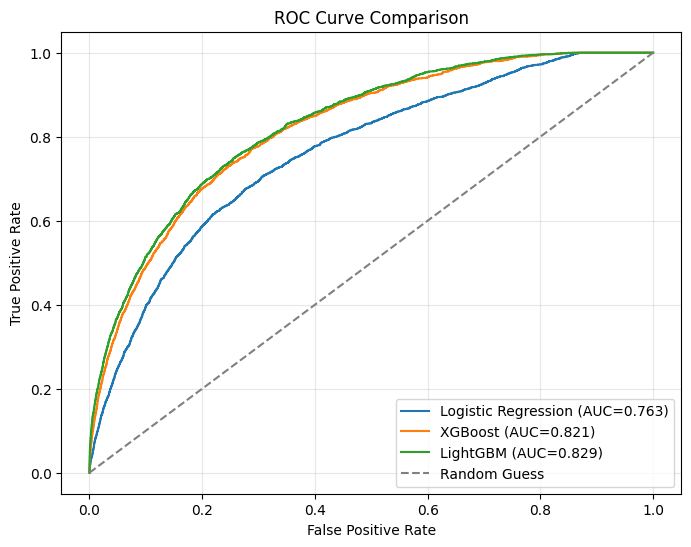

In [ ]:
# ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(
    y_test,
    lr_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})"
)


# XGBoost
fpr, tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_prob):.3f})"
)


# LightGBM
fpr, tpr, _ = roc_curve(
    y_test,
    lgbm_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM (AUC={roc_auc_score(y_test, lgbm_prob):.3f})"
)


# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Guess"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

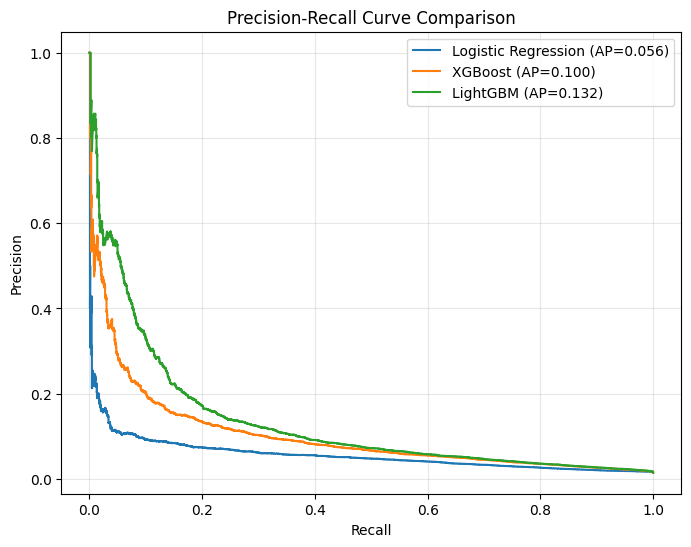

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))


# Logistic Regression
precision, recall, _ = precision_recall_curve(
    y_test,
    lr_prob
)

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (AP={average_precision_score(y_test, lr_prob):.3f})"
)


# XGBoost
precision, recall, _ = precision_recall_curve(
    y_test,
    xgb_prob
)

plt.plot(
    recall,
    precision,
    label=f"XGBoost (AP={average_precision_score(y_test, xgb_prob):.3f})"
)


# LightGBM
precision, recall, _ = precision_recall_curve(
    y_test,
    lgbm_prob
)

plt.plot(
    recall,
    precision,
    label=f"LightGBM (AP={average_precision_score(y_test, lgbm_prob):.3f})"
)


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Since fraudulent transactions represent only a small fraction of all transactions, PR-AUC was used as a more informative evaluation metric than ROC-AUC for measuring fraud detection performance.

*   Logistic Regression served as a baseline model. Tree-based ensemble methods substantially improved performance.
*   Among the evaluated models, LightGBM achieved the best overall performance, increasing ROC-AUC from 0.762 to 0.829 and PR-AUC from 0.056 to 0.132.
*   At the selected decision threshold, LightGBM also obtained the highest F1 score (0.186), demonstrating a better balance between fraud detection and false alarms than the other models.



## Model Evaluation

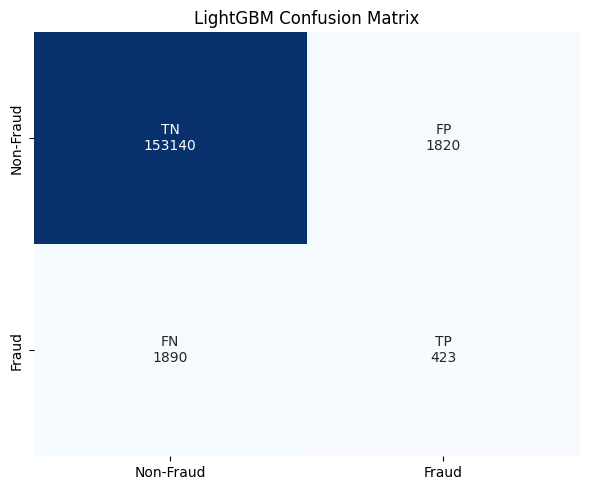

In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    lgbm_pred
)

tn, fp, fn, tp = cm.ravel()

labels = np.array([
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Non-Fraud","Fraud"],
    yticklabels=["Non-Fraud","Fraud"]
)

plt.title("LightGBM Confusion Matrix")

plt.tight_layout()
plt.show()

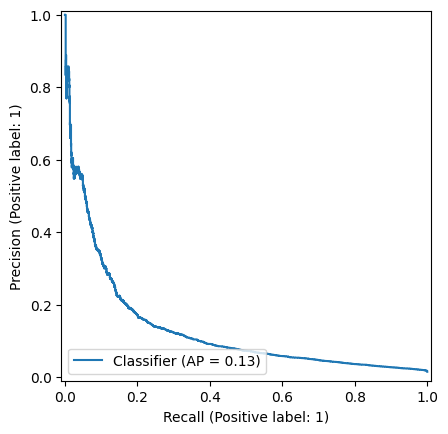

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    lgbm_prob
)

plt.show()

## Feature Importance & SHAP Value


*   Feature Importance

    *   It tells us Which features are most frequently or effectively used by the model for prediction.

    *   It does not tell us whether a higher feature value increases fraud risk; whether the relationship is positive or negative.


*   SHAP

    *   It tells us how each feature contributes to the prediction for individual observations and across the dataset.

    *   It can explain whether high values increase or decrease fraud probability; the magnitude of each feature's contribution; why a particular transaction is predicted as fraudulent.




In [ ]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm_model.feature_importances_
})

importance = (
    importance
    .sort_values("Importance", ascending=False)
)

importance.head(20)

,Feature,Importance
74,customerId_freq,1720
73,merchantName_freq,1582
12,account_age_days,948
28,customer_avg_amount,676
2,transactionAmount,597
13,days_since_address_change,557
3,currentBalance,545
1,availableMoney,537
15,days_to_expiry,480
0,creditLimit,454


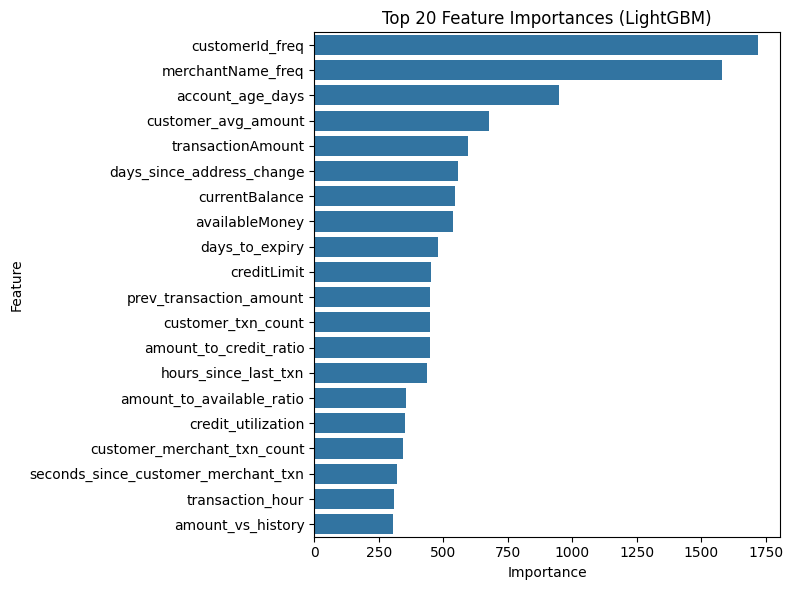

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances (LightGBM)")
plt.tight_layout()
plt.show()

Feature importance indicates that customer behavioral variables, including transaction frequency, merchant frequency, and historical spending patterns, were the most frequently used features during model construction. This highlights the importance of incorporating customer history into fraud detection models.

In [ ]:
# SHAP Value

explainer = shap.TreeExplainer(lgbm_model)

In [ ]:
# Sample 5,000 observations for visualization
X_shap = X_test.sample(
    n=5000,
    random_state=42
)

shap_values = explainer.shap_values(X_shap)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


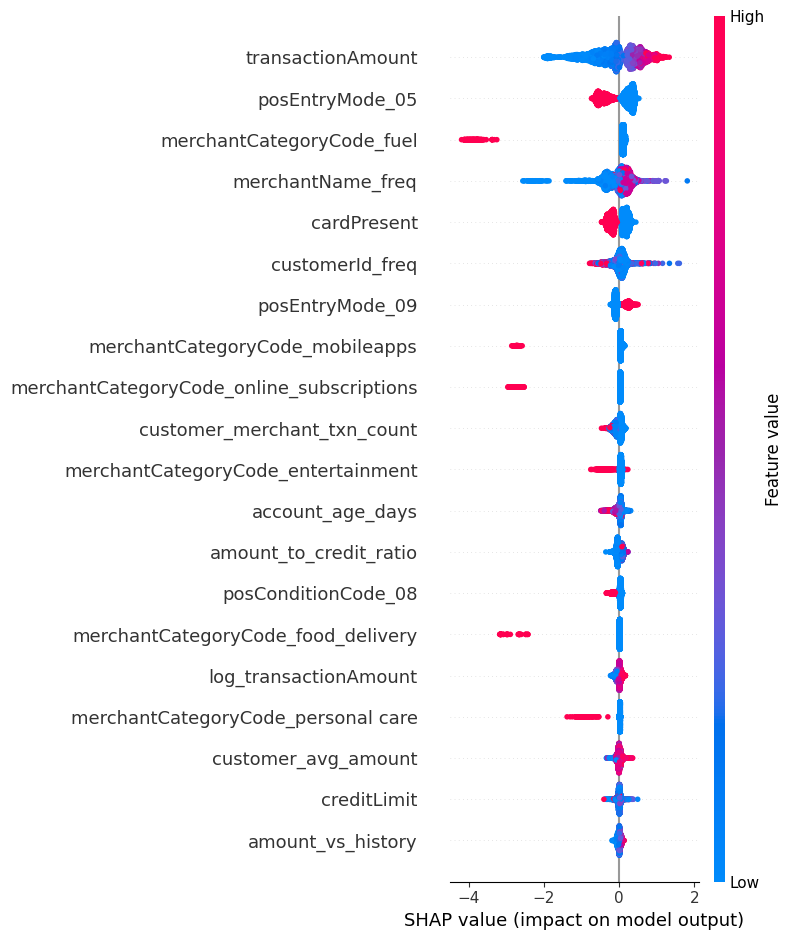

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()
plt.show()

SHAP analysis provided additional insights into the model's decision-making process. Transaction amount had the largest impact on prediction outcomes, followed by POS entry mode, merchant category, card-present status, and customer transaction history. These findings are generally consistent with the exploratory data analysis, suggesting that high-value transactions and customer behavioral patterns are strong indicators of potential fraud.

# Conclusion

*   Tree-based models substantially outperformed Logistic Regression.

*   Customer behavioral features were among the most important predictors.

*   Transaction amount remained the strongest individual predictor according to SHAP.

*   Historical customer–merchant interactions improved fraud detection performance.

*   LightGBM achieved the best overall balance between ranking performance (PR-AUC) and classification performance (F1-score).

# Future Work

*   optimizing LightGBM hyperparameters using Bayesian optimization or grid search

*   incorporating additional customer behavioral features, such as standardized transaction amount (z-score)

*   exploring temporal sequence models to better capture customer spending patterns.

In [ ]:
!pip freeze | grep -E "pandas|numpy|scikit|xgboost|lightgbm|shap|matplotlib|seaborn" > /content/drive/MyDrive/Fraud/requirements.txt